1. Initial Cleansing & Exploaration

#### First, you do some initial data cleaning and exploration. This includes inspecting the dataset, understanding the variables, checking distributions, correlations, missing values, and removing columns that clearly cannot be used for prediction (IDs, post-incident variables, timestamps of the incident itself, etc.). You have already done some of this. 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_new = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/df_new.xlsx')

In [9]:
df = df_new.copy()
df.head(2)

,Unnamed: 0,Addressbase UPRN,ABP_Classification_Desc,ABP_Classification_Code,Tenure_Desc,AgeBracket_EldParent,(H) Age - Fine,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,...,Property_Description,Description,Property_Code,VictimsInvolved,VictimType,WasRescued,Victim_Category,EvacuationAssistanceInvolved,EquipmentUsed,Incident?
0,0,10002188486,Detached,RD02,Owner,76+,11,0,4,12,...,0,0,0,0,0,0,0,0,0,N
1,1,10002188492,Semi-Detached,RD03,Owner,61 - 65,8,0,2,9,...,0,0,0,0,0,0,0,0,0,N


In [10]:
df.shape

(82314, 50)

In [11]:
df.rename(columns = {'Incident?':'INCIDENT'}, inplace = True)
df.head(2)

,Unnamed: 0,Addressbase UPRN,ABP_Classification_Desc,ABP_Classification_Code,Tenure_Desc,AgeBracket_EldParent,(H) Age - Fine,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,...,Property_Description,Description,Property_Code,VictimsInvolved,VictimType,WasRescued,Victim_Category,EvacuationAssistanceInvolved,EquipmentUsed,INCIDENT
0,0,10002188486,Detached,RD02,Owner,76+,11,0,4,12,...,0,0,0,0,0,0,0,0,0,N
1,1,10002188492,Semi-Detached,RD03,Owner,61 - 65,8,0,2,9,...,0,0,0,0,0,0,0,0,0,N


In [12]:
df['INCIDENT'].value_counts(normalize = True)

N    0.969203
Y    0.030797
Name: INCIDENT, dtype: float64

In [13]:
'''
mylabels = [f"N = {df['INCIDENT'].value_counts()[0]}", f"Y = {df['INCIDENT'].value_counts()[1]}"]
myexplode = [0.5, 0]
plt.pie(df['INCIDENT'].value_counts(), labels = mylabels, explode = myexplode, shadow = True)
plt.title('Incident = Y/N')
plt.show()
'''

'\nmylabels = [f"N = {df[\'INCIDENT\'].value_counts()[0]}", f"Y = {df[\'INCIDENT\'].value_counts()[1]}"]\nmyexplode = [0.5, 0]\nplt.pie(df[\'INCIDENT\'].value_counts(), labels = mylabels, explode = myexplode, shadow = True)\nplt.title(\'Incident = Y/N\')\nplt.show()\n'

## Note:
### The target feature ['INCIDENT'] is very far from being balanced.
##### When test_train_split >> Remember to set stratify = y

## .................

#### 1(a) Remove Redundant columns

In [14]:
df = df.drop(columns=['Addressbase UPRN','Unnamed: 0','Easting', 'Northing', 'CREATION_DATE',
       'FRSIncidentIdentifier', 'Year', 'Fiscal_Year', 'TimeOfCall',
       'ResponsiblePartyStationId', 'IncidentCategory', 'Property_Type',
       'Property_Description', 'Description', 'Property_Code',
       'VictimsInvolved', 'VictimType', 'WasRescued', 'Victim_Category',
       'EvacuationAssistanceInvolved', 'EquipmentUsed','ABP_Classification_Desc',
        'Household Acorn Category Description','Household Acorn Type Description_x',
        'Household Acorn Group Description', 'Household Acorn Type Description_y',
        '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag','Dependent Locality',
                      'Town','Station_Ground_Code',
                      '(H) Presence of Elderly Parent','AgeBracket_EldParent',
                      'Output Area'
                      
                     ])

In [15]:
df.shape

(82314, 16)

In [16]:
df.columns
df.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,LSOA11CD,Local Custodian Name,Household Acorn Group,Household Acorn Type_y,INCIDENT
0,RD02,Owner,11,4,12,11,19,0,8,1,5,E01028762,West Oxfordshire,1,2,N
1,RD03,Owner,8,2,9,11,16,0,3,1,9,E01028762,West Oxfordshire,2,3,N


## 1(b) Missing values?

In [17]:
print(df.isnull().sum())

ABP_Classification_Code              0
Tenure_Desc                          0
(H) Age - Fine                       0
(H) Number of Adults in Household    0
(H) Family Lifestage v3              0
(H) Length of Residency              0
(H) Affluence v2                     0
(H) Number of Children v3            0
(H) Household Income v3 - Bands      0
Household Acorn Category             0
Household Acorn Type_x               0
LSOA11CD                             0
Local Custodian Name                 0
Household Acorn Group                0
Household Acorn Type_y               0
INCIDENT                             0
dtype: int64


## Comment:
#### No null values are present.
#### Would it be worth performing Imputation here in case of null values being present in future datasets?

df.head(2)

# 1(c): Check distributions

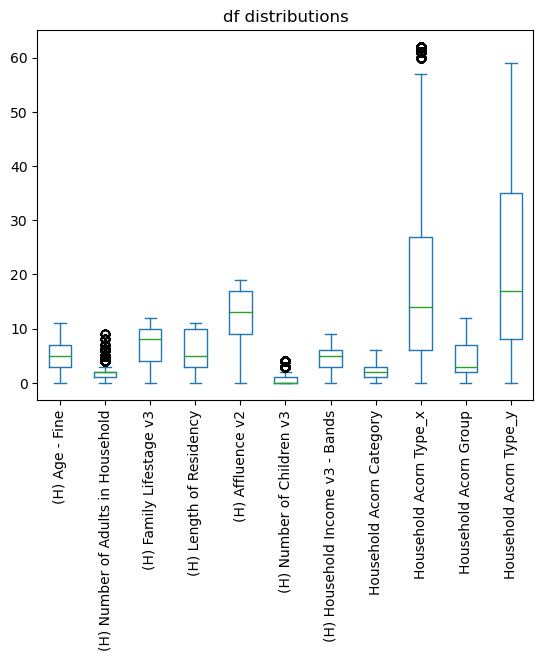

In [18]:
ax = df.plot.box()
plt.title('df distributions')
plt.xticks(rotation=90)
plt.show()

In [19]:
df.dtypes

ABP_Classification_Code              object
Tenure_Desc                          object
(H) Age - Fine                        int64
(H) Number of Adults in Household     int64
(H) Family Lifestage v3               int64
(H) Length of Residency               int64
(H) Affluence v2                      int64
(H) Number of Children v3             int64
(H) Household Income v3 - Bands       int64
Household Acorn Category              int64
Household Acorn Type_x                int64
LSOA11CD                             object
Local Custodian Name                 object
Household Acorn Group                 int64
Household Acorn Type_y                int64
INCIDENT                             object
dtype: object

### Comment:
#### These features are Ordinal categories -- do they require some sort of Scaling/Normalisation?

## 1(d): Correlation between features?

### for the .corr() function to operate, the target feature must be converted to numeric format:

### Replace the TARGET varable from Y/N to 0/1:¶

In [20]:
df['INCIDENT'].replace('N',0, inplace = True)
df['INCIDENT'].replace('Y',1, inplace = True)

df['INCIDENT'].dtype

dtype('int64')

In [21]:
from pandas.plotting import scatter_matrix

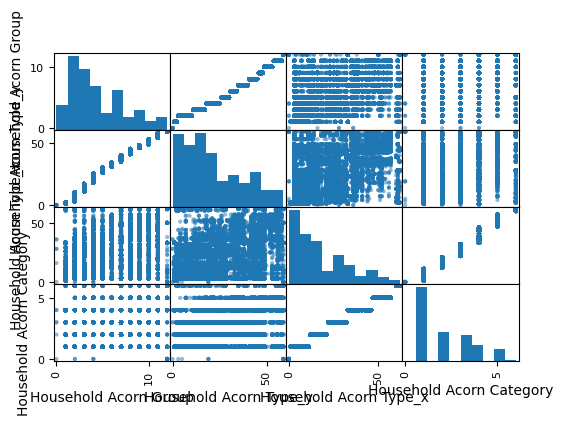

In [22]:
## for those features with positive correlation coefficients:

attributes = ['Household Acorn Group','Household Acorn Type_y','Household Acorn Type_x','Household Acorn Category']
scatter_matrix(df[attributes], figsize = (6,4))
#plt.title('features with POSITIVE correlation coefficients')

plt.show()

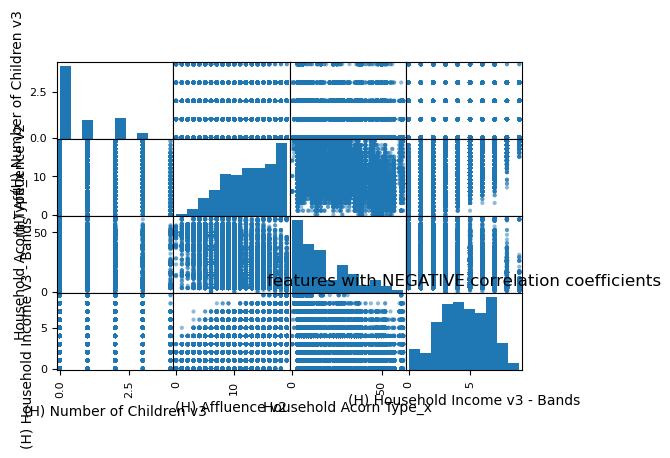

In [23]:
## for those features with NEGATIVE correlation coefficients:

attributes = ['(H) Number of Children v3','(H) Affluence v2','Household Acorn Type_x','(H) Household Income v3 - Bands']
scatter_matrix(df[attributes], figsize = (6,4))
plt.title('features with NEGATIVE correlation coefficients')

plt.show()

### Using the Pearson Correlation:

In [24]:
corr_pearson = df.corr()
corr_pearson['INCIDENT'].sort_values(ascending = False)

INCIDENT                             1.000000
Household Acorn Group                0.074549
Household Acorn Type_y               0.071001
Household Acorn Type_x               0.050459
Household Acorn Category             0.044154
(H) Age - Fine                       0.017898
(H) Length of Residency              0.016212
(H) Family Lifestage v3              0.007159
(H) Number of Adults in Household   -0.005767
(H) Number of Children v3           -0.026177
(H) Affluence v2                    -0.044805
(H) Household Income v3 - Bands     -0.054997
Name: INCIDENT, dtype: float64

Text(0.5, 1.0, 'Pearson Corr()')

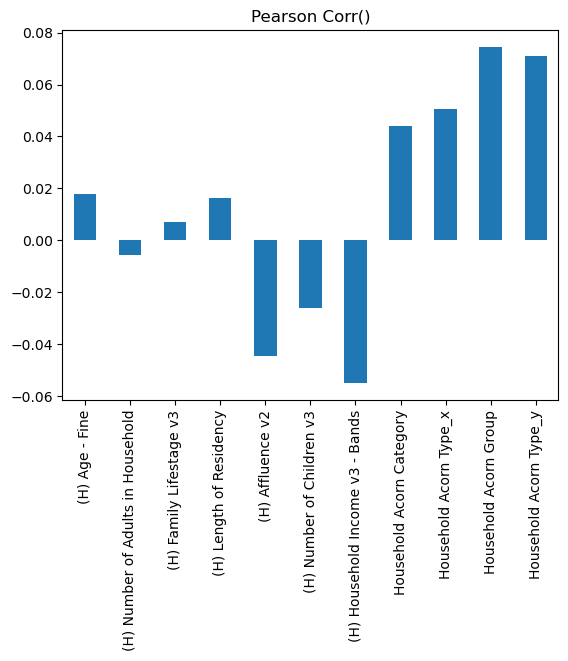

In [25]:
corr_pearson = df.corr()
corr_pearson['INCIDENT']
corr_pearson['INCIDENT'][:-1].plot(kind = 'bar')
plt.title('Pearson Corr()')

<AxesSubplot:>

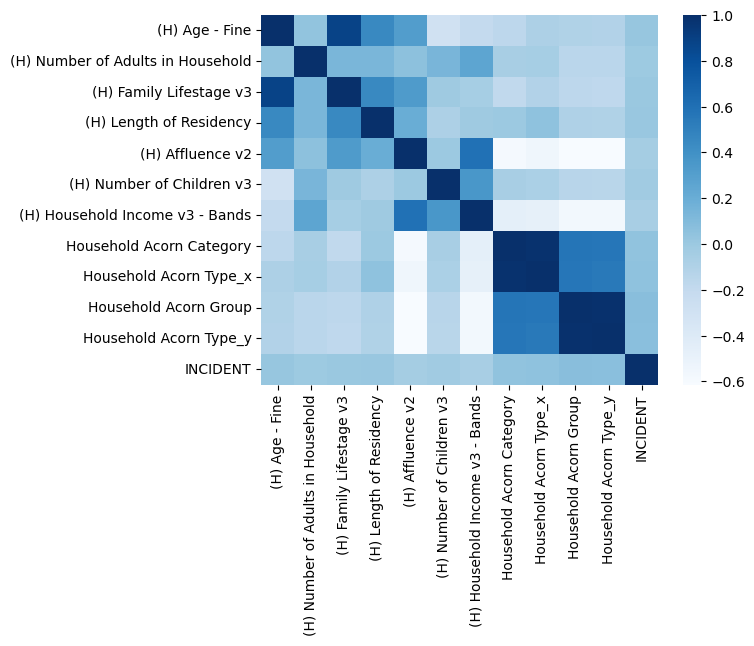

In [26]:
# calculate the correlation matrix on the numeric columns
corr_pearson = df.select_dtypes('number').corr()

# plot the heatmap
sns.heatmap(corr_pearson, cmap="Blues")

### Using the Spearman Correlation:

In [27]:
corr_spearman = df.corr('spearman')
corr_spearman['INCIDENT'].sort_values(ascending = False)

INCIDENT                             1.000000
Household Acorn Type_y               0.058500
Household Acorn Group                0.058305
Household Acorn Type_x               0.039198
Household Acorn Category             0.035277
(H) Age - Fine                       0.015238
(H) Length of Residency              0.014911
(H) Family Lifestage v3              0.009161
(H) Number of Adults in Household   -0.017104
(H) Number of Children v3           -0.028178
(H) Affluence v2                    -0.037921
(H) Household Income v3 - Bands     -0.052295
Name: INCIDENT, dtype: float64

Text(0.5, 1.0, 'Spearman Corr()')

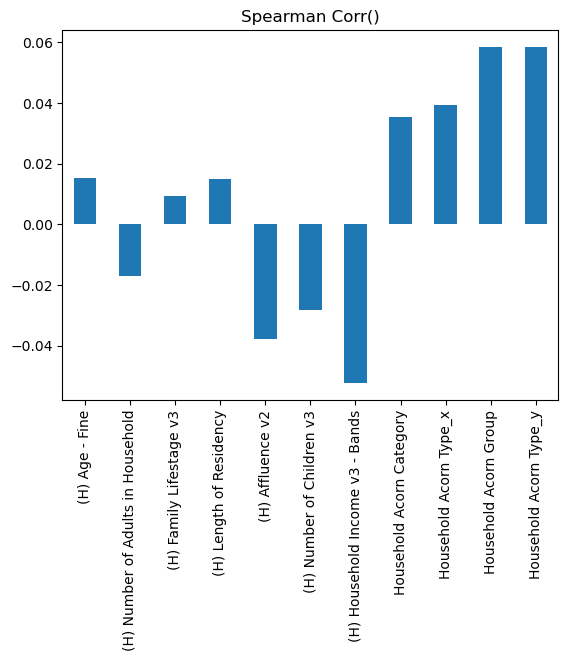

In [28]:
corr_spearman = df.corr('spearman')
corr_spearman['INCIDENT']
corr_spearman['INCIDENT'][:-1].plot(kind = 'bar')
plt.title('Spearman Corr()')

<AxesSubplot:>

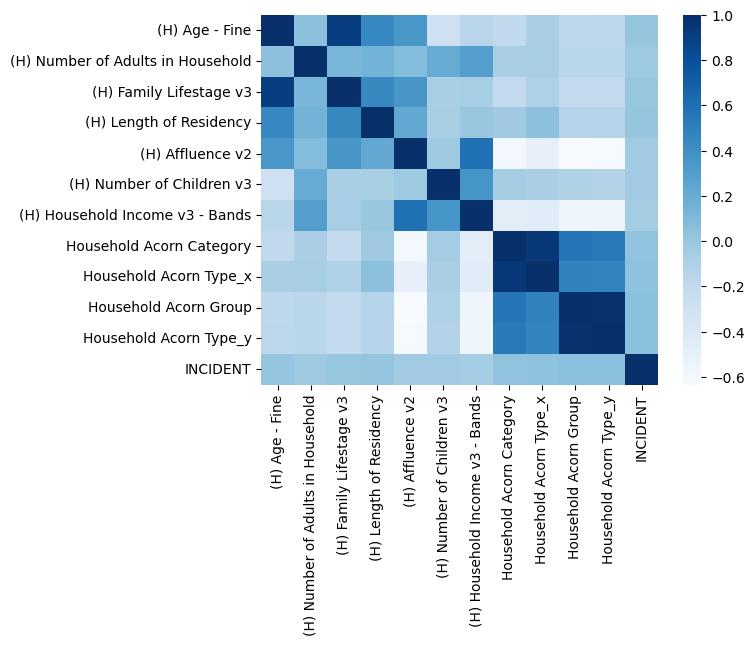

In [29]:
# calculate the correlation matrix on the numeric columns
corr_spearman = df.select_dtypes('number').corr('spearman')

# plot the heatmap
sns.heatmap(corr_spearman, cmap="Blues")

In [30]:
#corrs = corr_p.merge(corr_sp, shared_index = True)
corr_pearson_df = pd.DataFrame(corr_pearson['INCIDENT'])
corr_pearson_df.rename(columns = {'INCIDENT': 'PEARSON_COEFFICIENT'}, inplace = True)

corr_spearman_df = pd.DataFrame(corr_spearman['INCIDENT'])
corr_spearman_df.rename(columns = {'INCIDENT': 'SPEARMAN_COEFFICIENT'}, inplace = True)

In [31]:
corr_pearson_df

,PEARSON_COEFFICIENT
(H) Age - Fine,0.017898
(H) Number of Adults in Household,-0.005767
(H) Family Lifestage v3,0.007159
(H) Length of Residency,0.016212
(H) Affluence v2,-0.044805
(H) Number of Children v3,-0.026177
(H) Household Income v3 - Bands,-0.054997
Household Acorn Category,0.044154
Household Acorn Type_x,0.050459
Household Acorn Group,0.074549


In [32]:
corr_spearman_df

,SPEARMAN_COEFFICIENT
(H) Age - Fine,0.015238
(H) Number of Adults in Household,-0.017104
(H) Family Lifestage v3,0.009161
(H) Length of Residency,0.014911
(H) Affluence v2,-0.037921
(H) Number of Children v3,-0.028178
(H) Household Income v3 - Bands,-0.052295
Household Acorn Category,0.035277
Household Acorn Type_x,0.039198
Household Acorn Group,0.058305


In [33]:
corrs_df = pd.concat([corr_pearson_df, corr_spearman_df], axis=1)
corrs_df

,PEARSON_COEFFICIENT,SPEARMAN_COEFFICIENT
(H) Age - Fine,0.017898,0.015238
(H) Number of Adults in Household,-0.005767,-0.017104
(H) Family Lifestage v3,0.007159,0.009161
(H) Length of Residency,0.016212,0.014911
(H) Affluence v2,-0.044805,-0.037921
(H) Number of Children v3,-0.026177,-0.028178
(H) Household Income v3 - Bands,-0.054997,-0.052295
Household Acorn Category,0.044154,0.035277
Household Acorn Type_x,0.050459,0.039198
Household Acorn Group,0.074549,0.058305


<AxesSubplot:>

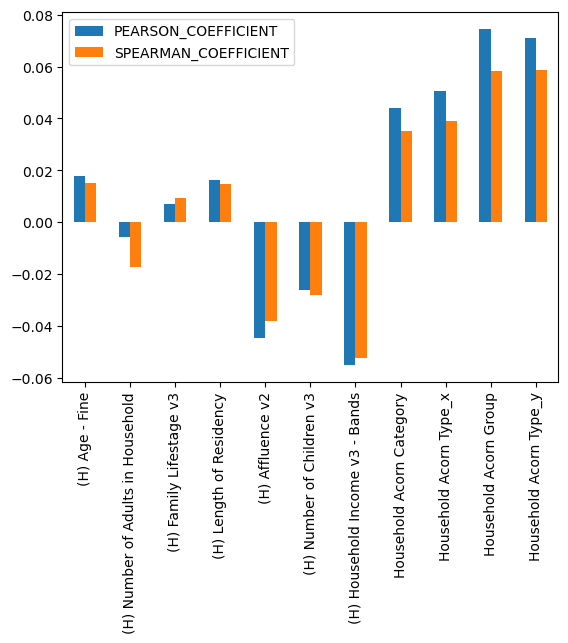

In [34]:
corrs_df[:-1].plot(kind = 'bar')

## The extremely low correlation coeffiicents between MAIN FEATURES (X) and the TARGET FEATURES (y) demonstrate that a linear correlation will not be suitable for modelling this data.


# ....................

# PART 2:
# 2(a) SPLIT THE DATA:
#### Next, you define the target and features. This means separating the dataset into the input variables (X) and the target variable (y), which in your case is the Incident column.

In [35]:
df = pd.DataFrame(df)
df.columns

Index(['ABP_Classification_Code', 'Tenure_Desc', '(H) Age - Fine',
       '(H) Number of Adults in Household', '(H) Family Lifestage v3',
       '(H) Length of Residency', '(H) Affluence v2',
       '(H) Number of Children v3', '(H) Household Income v3 - Bands',
       'Household Acorn Category', 'Household Acorn Type_x', 'LSOA11CD',
       'Local Custodian Name', 'Household Acorn Group',
       'Household Acorn Type_y', 'INCIDENT'],
      dtype='object')

In [36]:
cols = []
for c in df.columns:
    cols.append(c)
cols

['ABP_Classification_Code',
 'Tenure_Desc',
 '(H) Age - Fine',
 '(H) Number of Adults in Household',
 '(H) Family Lifestage v3',
 '(H) Length of Residency',
 '(H) Affluence v2',
 '(H) Number of Children v3',
 '(H) Household Income v3 - Bands',
 'Household Acorn Category',
 'Household Acorn Type_x',
 'LSOA11CD',
 'Local Custodian Name',
 'Household Acorn Group',
 'Household Acorn Type_y',
 'INCIDENT']

In [37]:
# target data
y = df[cols[-1]]
y

0        0
1        0
2        0
3        0
4        0
        ..
82309    0
82310    0
82311    0
82312    0
82313    0
Name: INCIDENT, Length: 82314, dtype: int64

In [38]:
X_cols = cols[0:len(cols)-1]
X = df[df.columns.intersection(X_cols)]
X.shape
X.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,LSOA11CD,Local Custodian Name,Household Acorn Group,Household Acorn Type_y
0,RD02,Owner,11,4,12,11,19,0,8,1,5,E01028762,West Oxfordshire,1,2
1,RD03,Owner,8,2,9,11,16,0,3,1,9,E01028762,West Oxfordshire,2,3


#### After defining the X, y features:
#### ...perform a train/test split. The reason we do this relatively early is so that part of the data remains completely unseen during training. This allows us to properly evaluate whether the model generalises well.

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,stratify = y)

In [40]:
X.shape

(82314, 15)

In [41]:
X_train.shape

(65851, 15)

In [42]:
1-(X_train.shape[0]/X.shape[0])

0.20000242972033921

# PART 3: FEATURE ENGINEERING
Then comes feature engineering and preprocessing. This includes things like one-hot encoding categorical variables and scaling or normalising numeric variables. In practice, these transformations are fitted using the training data and then applied to the test data. The goal is to avoid introducing bias or “data leakage” from the test set.

## NOTE: Any Feature engineering takes place on the X_train dataset

In [43]:
X_train.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,LSOA11CD,Local Custodian Name,Household Acorn Group,Household Acorn Type_y
27337,RD06,Owner,2,1,0,2,13,0,5,1,3,E01028691,Vale of White Horse,5,28
79982,RD04,Owner,1,1,3,2,13,1,4,4,35,E01028446,Cherwell,7,38


In [44]:
X_train.dtypes

ABP_Classification_Code              object
Tenure_Desc                          object
(H) Age - Fine                        int64
(H) Number of Adults in Household     int64
(H) Family Lifestage v3               int64
(H) Length of Residency               int64
(H) Affluence v2                      int64
(H) Number of Children v3             int64
(H) Household Income v3 - Bands       int64
Household Acorn Category              int64
Household Acorn Type_x                int64
LSOA11CD                             object
Local Custodian Name                 object
Household Acorn Group                 int64
Household Acorn Type_y                int64
dtype: object

In [45]:
# feature == float64
X_train_floats = X_train.dtypes[X_train.dtypes == 'float64']
print(f'The are {len(X_train_floats)} float64 formats present >>>') 

The are 0 float64 formats present >>>


### feature == integer

In [46]:
# feature == integer

X_train_int = X_train.dtypes[X_train.dtypes == 'int64']
X_train_int = X_train.select_dtypes('int64')
print(f'The are {X_train_int.shape[1]} float64 formats present >>>') 

X_train_int.head(4)

The are 11 float64 formats present >>>


,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
27337,2,1,0,2,13,0,5,1,3,5,28
79982,1,1,3,2,13,1,4,4,35,7,38
39637,7,2,9,4,14,0,4,1,9,2,8
59885,11,2,12,10,19,0,7,1,10,1,2


### Whereby it's possible to view the histograms of the int64 format features:

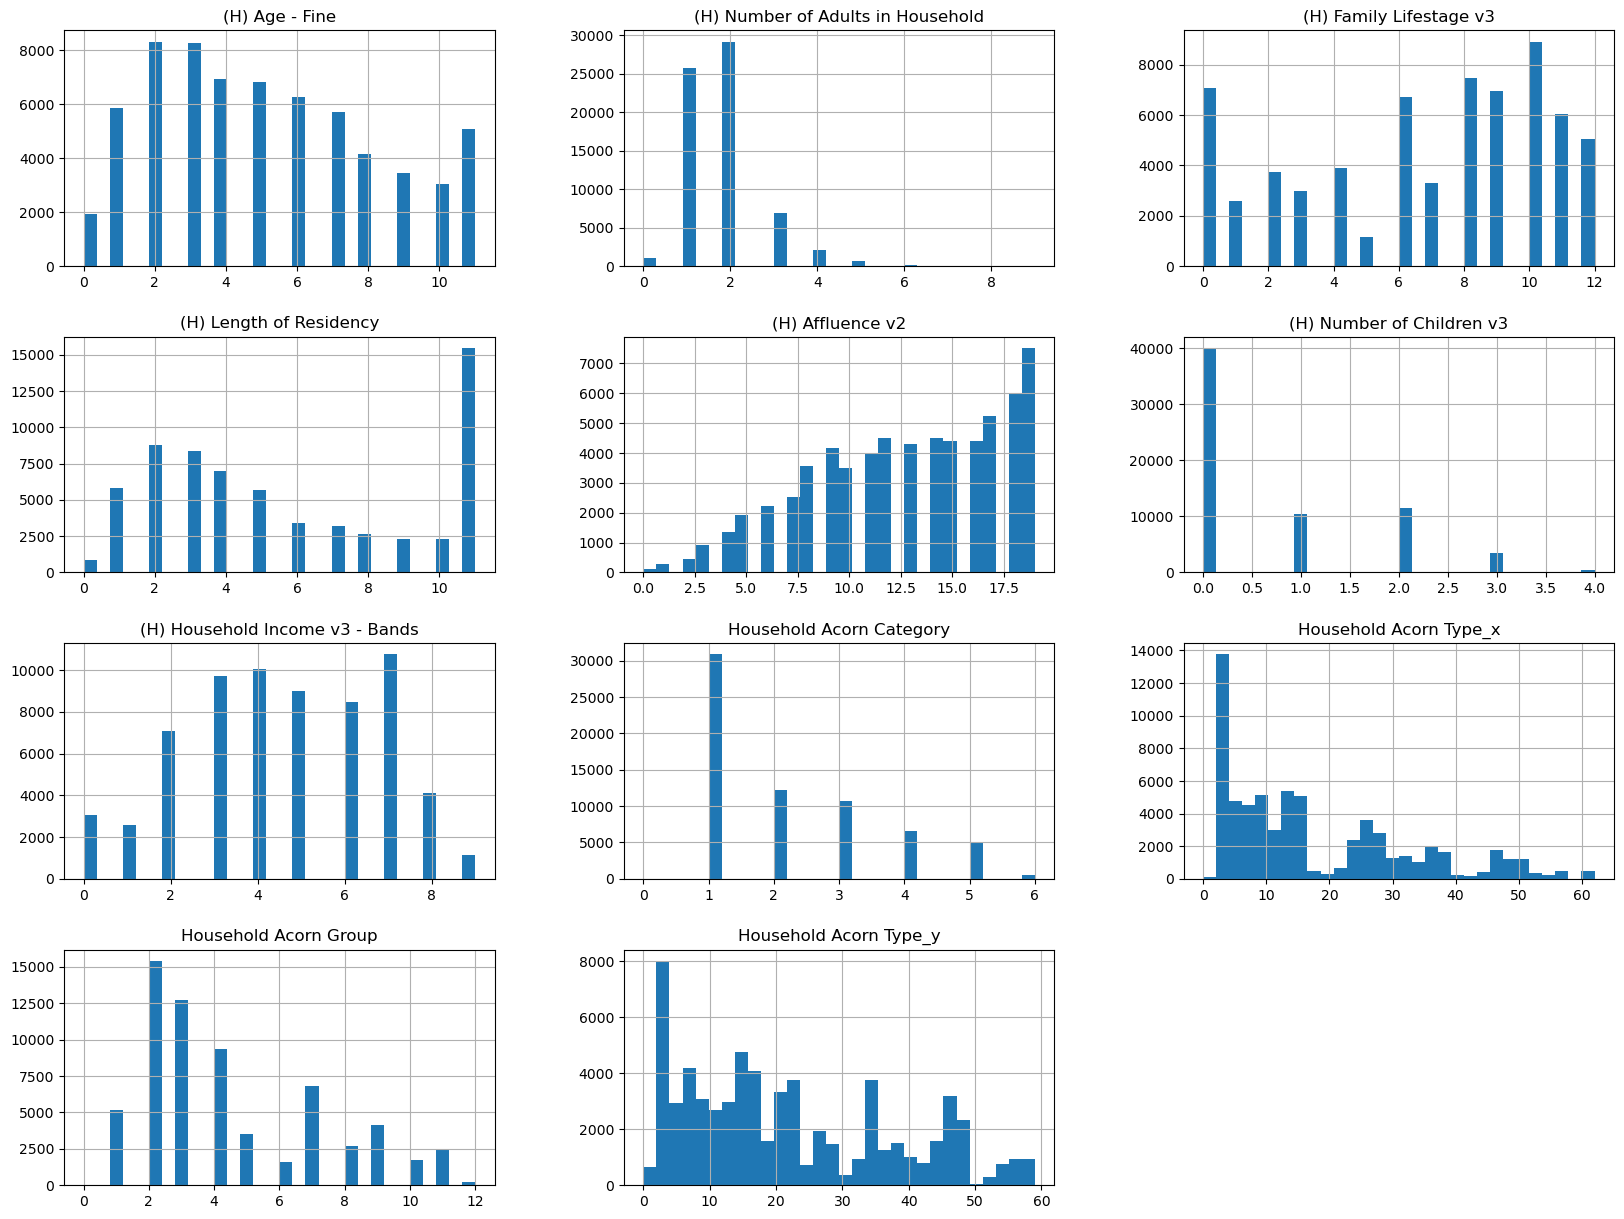

In [47]:
X_train_int.hist(bins = 30,figsize = (20,15));
plt.show()

### As well as viewing the distributions of the int64 features:

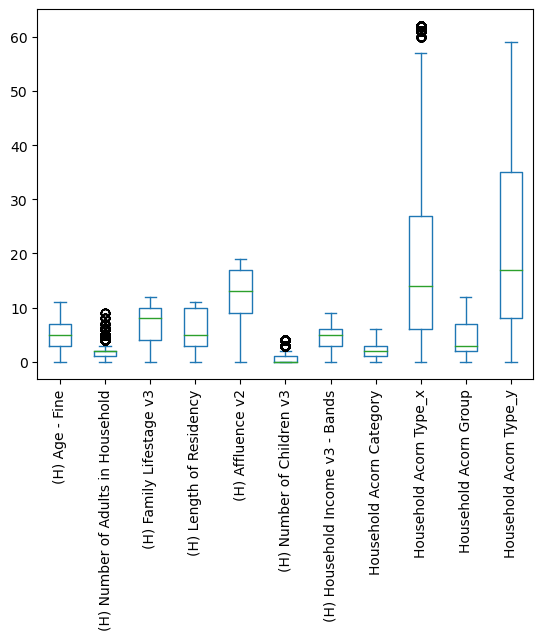

In [48]:
ax = X_train_int.plot.box()
plt.xticks(rotation=90)
plt.show()

### feature == object

In [49]:
# feature == object

X_train_obj = X_train.dtypes[X_train.dtypes == 'object']
X_train_obj = X_train.select_dtypes('object')
print(f'The are {X_train_obj.shape[1]} float64 formats present >>>') 

print(f'X_train.shape = {X_train_obj.shape}')
X_train_obj.head(4)


The are 4 float64 formats present >>>
X_train.shape = (65851, 4)


,ABP_Classification_Code,Tenure_Desc,LSOA11CD,Local Custodian Name
27337,RD06,Owner,E01028691,Vale of White Horse
79982,RD04,Owner,E01028446,Cherwell
39637,RD03,Owner,E01028423,Cherwell
59885,RD02,Owner,E01028645,South Oxfordshire


In [50]:
for col in X_train_obj.columns:
    print(f'{col}: {X_train_obj[col].nunique()} unique values')
#X_train_obj['ABP_Classification_Code'].value_counts()

ABP_Classification_Code: 4 unique values
Tenure_Desc: 3 unique values
LSOA11CD: 400 unique values
Local Custodian Name: 5 unique values


In [51]:
X_train_obj[['LSOA11CD']].describe()

,LSOA11CD
count,65851
unique,400
top,E01028424
freq,2041


### Comment:

##### Ordinal Encoding will be suitable for LSOA11CD?
### The datapoints for LSOA11CD are not ordinal, their maginitude holds no significance in terms of quantification of any feature.

### Options here:
#### <u>OneHotEncoder.</u> -- yes. ideal since it will contribute 400 additional columns consistingof a sparse matrix with binary contents, very computationally efficient 

#### <u>Ordinal encoder.</u> -- no. this will categorise the contents of LSOA11CD with respect to an ordinal nature, potentially distorting future algorithms we may use.

#### <u>LabelEncoder.</u> -- no, for the same reasons as OrdinalEncoding

### OneHotEncoding for LSOA11CD

In [54]:
X_train_obj_ohe = X_train_obj
X_train_obj_ohe.sample(3)

,ABP_Classification_Code,Tenure_Desc,LSOA11CD,Local Custodian Name
71226,RD04,Council/HA,E01028745,Vale of White Horse
41867,RD03,Owner,E01028765,West Oxfordshire
64419,RD04,Owner,E01028737,Vale of White Horse


In [55]:
X_train_obj.columns

Index(['ABP_Classification_Code', 'Tenure_Desc', 'LSOA11CD',
       'Local Custodian Name'],
      dtype='object')

In [78]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown = 'ignore', sparse = False)
ohe

OneHotEncoder(handle_unknown='ignore', sparse=False)

In [79]:
X = X_train_obj[['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name','LSOA11CD']]

encoded = ohe.fit_transform(X)
feature_names = ohe.get_feature_names_out(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name','LSOA11CD'])

X_train_obj_ohe = pd.DataFrame(encoded, columns = feature_names)
X_train_obj_ohe.head(2)


,ABP_Classification_Code_RD02,ABP_Classification_Code_RD03,ABP_Classification_Code_RD04,ABP_Classification_Code_RD06,Tenure_Desc_Council/HA,Tenure_Desc_Owner,Tenure_Desc_Rental,Local Custodian Name_Cherwell,Local Custodian Name_Oxford,Local Custodian Name_South Oxfordshire,...,LSOA11CD_E01032948,LSOA11CD_E01032949,LSOA11CD_E01032950,LSOA11CD_E01032951,LSOA11CD_E01032952,LSOA11CD_E01032953,LSOA11CD_E01032954,LSOA11CD_E01033282,LSOA11CD_E01033305,LSOA11CD_E01033306
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### After all the 'order' for the feature is not important
#### Next the LabelEncoder method is attempted:


### We make two versions:
## X_train_obj  >>  we drop the LSOA11CD feature and carry on without it.


In [80]:
X_train_obj_without_LSOA = X_train_obj.drop(['LSOA11CD'], axis=1)

In [81]:
X_train_obj_without_LSOA.columns

Index(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'], dtype='object')

### To One hot encode this dataset: run the following:

In [84]:

X = X_train_obj_without_LSOA[['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name']]

encoded = ohe.fit_transform(X)
feature_names = ohe.get_feature_names_out(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'])

X_train_obj_without_LSOA_ohe = pd.DataFrame(encoded, columns = feature_names)
X_train_obj_without_LSOA_ohe.head(2)

,ABP_Classification_Code_RD02,ABP_Classification_Code_RD03,ABP_Classification_Code_RD04,ABP_Classification_Code_RD06,Tenure_Desc_Council/HA,Tenure_Desc_Owner,Tenure_Desc_Rental,Local Custodian Name_Cherwell,Local Custodian Name_Oxford,Local Custodian Name_South Oxfordshire,Local Custodian Name_Vale of White Horse,Local Custodian Name_West Oxfordshire
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### For the other X_train objects  do some: OneHotEncoding:

# OneHotEncoding:

# For numerical data:

In [85]:
X_train_int.head(2)

,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
27337,2,1,0,2,13,0,5,1,3,5,28
79982,1,1,3,2,13,1,4,4,35,7,38


In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_int)

X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_train_scaled_df


feature_names = scaler.feature_names_in_
feature_names

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = feature_names)
X_train_scaled_df.head(2)

,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
0,-1.004521,-0.881586,-1.759688,-1.04098,0.038744,-0.707877,0.200647,-0.855089,-1.025289,0.200194,0.389285
1,-1.326136,-0.881586,-0.973513,-1.04098,0.038744,0.319211,-0.251027,1.376186,1.166849,0.911019,1.011545


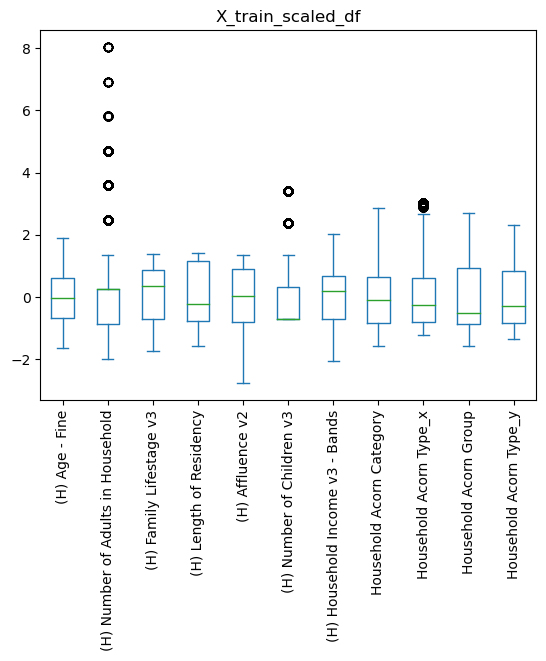

In [87]:
ax = X_train_scaled_df.plot.box()
plt.xticks(rotation=90)
plt.title('X_train_scaled_df')
plt.show()

In [117]:
X_train_F_Eng = pd.merge(X_train_obj_ohe, X_train_scaled_df, left_index=True, right_index=True, how ='inner')

In [118]:
X_train_F_Eng.shape

(65851, 423)

In [123]:
X_train_F_Eng.head(3)

,ABP_Classification_Code_RD02,ABP_Classification_Code_RD03,ABP_Classification_Code_RD04,ABP_Classification_Code_RD06,Tenure_Desc_Council/HA,Tenure_Desc_Owner,Tenure_Desc_Rental,Local Custodian Name_Cherwell,Local Custodian Name_Oxford,Local Custodian Name_South Oxfordshire,...,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.881586,-1.759688,-1.040980,0.038744,-0.707877,0.200647,-0.855089,-1.025289,0.200194,0.389285
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.881586,-0.973513,-1.040980,0.038744,0.319211,-0.251027,1.376186,1.166849,0.911019,1.011545
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.234845,0.598837,-0.494833,0.255088,-0.707877,-0.251027,-0.855089,-0.614263,-0.866044,-0.855235


In [105]:

columns = X_train_Engineered.columns
def f_cols(columns, q):
    list = []
    if q == 'Y':
        for c in columns:
            list.append(c)
    return list
f_cols(columns, 'N')

[]

# PART 4: MODEL TRAINING

Finally, you train the model (for example logistic regression) using the processed training data, and then evaluate its performance using metrics such as accuracy, precision, recall, or ROC-AUC.

In [109]:
### Linear Regression Trial

In [127]:
X_train_F_Eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65851 entries, 0 to 65850
Columns: 423 entries, ABP_Classification_Code_RD02 to Household Acorn Type_y
dtypes: float64(423)
memory usage: 212.5 MB


In [128]:
from sklearn.linear_model import LinearRegression

In [129]:
lr_model = LinearRegression()
lr_model.fit(X_train_F_Eng, y_train)

LinearRegression()

In [131]:
print(lr_model.score(X_train_F_Eng, y_train))

0.03597028075858033


# LOGISTIC REGRESSION

In [145]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression(max_iter = 300)
lg_model.fit(X_train_F_Eng, y_train)

LogisticRegression(max_iter=300)

In [146]:
print(lg_model.score(X_train_F_Eng, y_train))

0.9691424579733033


In [171]:
iter_steps = [100,200,300,400,500]
score = []
for i in iter_steps:
    lg_model = LogisticRegression(max_iter = i)
    lg_model.fit(X_train_F_Eng, y_train)
    
    score.append(lg_model.score(X_train_F_Eng, y_train))
score
    

c:\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

[0.9691424579733033,
 0.9691424579733033,
 0.9691424579733033,
 0.9691424579733033,
 0.9691424579733033]

In [172]:
# on the model where LSOA11CD is dropped:
X_train_obj_without_LSOA_ohe.head(2)
X_train_obj_without_LSOA = pd.merge(X_train_obj_without_LSOA_ohe, X_train_scaled_df, left_index=True, right_index=True, how ='inner')
X_train_obj_without_LSOA.head(2)


,ABP_Classification_Code_RD02,ABP_Classification_Code_RD03,ABP_Classification_Code_RD04,ABP_Classification_Code_RD06,Tenure_Desc_Council/HA,Tenure_Desc_Owner,Tenure_Desc_Rental,Local Custodian Name_Cherwell,Local Custodian Name_Oxford,Local Custodian Name_South Oxfordshire,...,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.881586,-1.759688,-1.04098,0.038744,-0.707877,0.200647,-0.855089,-1.025289,0.200194,0.389285
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.881586,-0.973513,-1.04098,0.038744,0.319211,-0.251027,1.376186,1.166849,0.911019,1.011545


In [175]:
iter_steps = [100,200,300,400,500]
score_without_LSOA = []
for i in iter_steps:
    lg_model_without_LSOA = LogisticRegression(max_iter = i)
    lg_model_without_LSOA.fit(X_train_obj_without_LSOA, y_train)
    
    score_without_LSOA.append(lg_model_without_LSOA.score(X_train_obj_without_LSOA, y_train))
score_without_LSOA
    

[0.9692032011662693,
 0.9692032011662693,
 0.9692032011662693,
 0.9692032011662693,
 0.9692032011662693]

In [176]:
score[0], score_without_LSOA[0]

(0.9691424579733033, 0.9692032011662693)

# Other notes from Goncalo
4th March 2026
Regarding your specific question about the order of operations, I hope the answer is now clear. Conceptually, we split the data first, and then perform the preprocessing steps. The reason is that we want the preprocessing to be based only on the training data. However, in notebooks it can sometimes look easier to encode first and split afterwards. The important principle is simply that the transformations should be derived from the training data rather than the full dataset.

One reason the steps may currently feel disconnected is that the notebook is performing several techniques (pairplots, encoding, scaling, modelling) without yet tying them into a clear modelling pipeline. It may help to think about the purpose of each step. Exploratory analysis helps you understand the data. Encoding converts categorical variables into numbers so that models can use them. Scaling ensures numeric variables are on comparable ranges, which is important for algorithms such as logistic regression. The model then learns the relationship between the features and whether an incident occurs. From what you’ve shared, you are actually making good progress. You have inspected the dataset, reduced the number of features, identified the target variable, and started thinking about encoding and modelling. The next step is simply to organise these pieces into a clearer pipeline rather than treating them as completely separate experiments.

I hope that makes sense, but please feel free to share the results that you have so far. 

Kind regards,
Gonçalo


## Going forward


#### Performance metrics for logistic model (basemodel)
## accuarcy
## Precision / Recall 
## F1

### optimisation and additional models such as Random Forest (composed Decision Tree)

### feature engineer based upon metrics

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
 
# 1. Define which columns get which treatment

num_cols = ['(H) Age - Fine', '(H) Number of Adults in Household', '(H) Length of Residency', '(H) Affluence v2']

cat_cols = ['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name']
 
# 2. Create the transformers

preprocessor = ColumnTransformer(

    transformers=[

        ('num', StandardScaler(), num_cols),

        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)

    ], remainder='drop') # This automatically drops LSOA11CD and anything not listed above# 3. Bundle it all with your model

pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(class_weight='balanced', max_iter=500)) 
# Note: class_weight='balanced' forces the model to pay attention to the 3% of fires.

])
 
# 4. Fit the pipeline on training data

pipeline.fit(X_train, y_train)
 
# 5. Evaluate on TEST data (which you haven't done yet!)

y_test_pred = pipeline.predict(X_test)
 

In [ ]:
y_test_pred